# Air Pollution Prediction in Major Indian Cities
## Exploratory Data Analysis and Statistical Analysis

### Objective

This notebook explores the patterns and statistical relationships in daily air pollution and meteorological data for five major Indian cities:

- Bengaluru
- Chennai
- Delhi
- Kolkata
- Mumbai

The analysis covers the period from January 2020 to December 2021.

The primary objective of the overall project is to develop machine-learning models capable of predicting **next-day PM2.5 concentration** using historical pollution levels, meteorological conditions, temporal information, and city-level characteristics.

### Analysis in This Notebook

This notebook includes:

1. Dataset validation
2. Exploratory Data Analysis (EDA)
3. PM2.5 distribution analysis
4. City-wise and temporal pollution patterns
5. Correlation analysis
6. Hypothesis testing
7. Multicollinearity assessment using Variance Inflation Factor (VIF)

Feature engineering and predictive modeling are performed in subsequent notebooks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Saving air_pollution_weather_cleaned_2020_2021 (1).csv to air_pollution_weather_cleaned_2020_2021 (1).csv
Dataset loaded successfully.
Shape: (3655, 13)


,Date,City,PM2.5,PM10,NO2,SO2,O3,CO,Temperature_Mean,Relative_Humidity_Mean,Precipitation,Wind_Speed_Max,Surface_Pressure_Mean
0,2020-01-01,Bengaluru,26.703125,66.219618,31.506189,6.228033,30.566349,247.754587,21.6,80,1.9,18.5,915.0
1,2020-01-02,Bengaluru,24.315661,62.571429,28.996195,5.079903,21.913704,864.569079,22.4,77,1.0,15.1,916.0
2,2020-01-03,Bengaluru,29.665271,72.838235,29.614459,5.535566,30.127463,668.727273,23.0,73,0.0,14.0,915.0
3,2020-01-04,Bengaluru,55.235786,114.010870,35.472778,6.702294,38.663864,1069.550189,23.4,70,0.0,13.2,913.6
4,2020-01-05,Bengaluru,51.294156,101.563218,30.340575,8.320714,43.419048,688.467578,23.3,73,0.2,16.6,913.4


## 1. Dataset Overview

The processed dataset combines cleaned OpenAQ pollution measurements with daily meteorological observations.

Each row represents one city on one calendar day.

The dataset contains six pollution indicators:

- PM2.5
- PM10
- NO2
- SO2
- O3
- CO

and five meteorological variables:

- Mean temperature
- Mean relative humidity
- Precipitation
- Maximum wind speed
- Mean surface pressure

Before exploratory analysis, the structure, date coverage, duplicate records, and missing values are examined.

In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nCities:")
print(df["City"].value_counts())

print("\nDuplicate City-Date rows:")
print(df.duplicated(["City", "Date"]).sum())

Dataset shape:
(3655, 13)

Columns:
['Date', 'City', 'PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO', 'Temperature_Mean', 'Relative_Humidity_Mean', 'Precipitation', 'Wind_Speed_Max', 'Surface_Pressure_Mean']

Data types:
Date                      datetime64[ns]
City                              object
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
O3                               float64
CO                               float64
Temperature_Mean                 float64
Relative_Humidity_Mean             int64
Precipitation                    float64
Wind_Speed_Max                   float64
Surface_Pressure_Mean            float64
dtype: object

Date range:
2020-01-01 00:00:00 to 2021-12-31 00:00:00

Cities:
City
Bengaluru    731
Chennai      731
Delhi        731
Kolkata      731
Mumbai       731
Name: count, dtype: int64

Duplicate City-Date rows:
0


In [ ]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
)

,Missing_Count,Missing_Percentage
PM2.5,152,4.16
PM10,331,9.06
NO2,275,7.52
SO2,276,7.55
O3,274,7.50
CO,274,7.50


### Missing Data Note

Short internal gaps of up to three consecutive days in the pollution time series were interpolated during data preparation.

Longer gaps were intentionally retained as missing values to avoid generating artificial pollution patterns through excessive interpolation.

Missing observations will therefore be handled carefully during subsequent statistical analysis and model preparation rather than being automatically replaced using global mean or median values.

In [ ]:
numeric_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "O3",
    "CO",
    "Temperature_Mean",
    "Relative_Humidity_Mean",
    "Precipitation",
    "Wind_Speed_Max",
    "Surface_Pressure_Mean"
]

descriptive_stats = (
    df[numeric_columns]
    .describe()
    .T
    .round(2)
)

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
PM2.5,3503.0,50.87,57.38,0.0,18.58,30.65,62.68,985.00
PM10,3324.0,102.09,89.77,0.0,42.49,70.60,137.72,786.77
NO2,3380.0,23.24,17.83,0.0,10.16,16.86,31.56,118.89
SO2,3379.0,9.35,5.07,0.0,5.99,8.11,11.62,99.02
O3,3381.0,28.37,16.16,0.0,17.26,25.18,37.12,193.86
CO,3381.0,780.69,482.34,0.0,472.44,710.00,966.67,9740.00
Temperature_Mean,3655.0,25.56,4.27,9.7,23.00,26.50,28.50,37.00
Relative_Humidity_Mean,3655.0,73.19,14.03,16.0,65.00,76.00,84.00,96.00
Precipitation,3655.0,4.46,11.90,0.0,0.00,0.20,4.20,199.90
Wind_Speed_Max,3655.0,16.95,5.34,5.6,13.20,16.40,20.00,68.90


In [ ]:
city_pm25_summary = (
    df.groupby("City")["PM2.5"]
    .agg(
        Observations="count",
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
    .sort_values("Mean", ascending=False)
)

display(city_pm25_summary)

,Observations,Mean,Median,Std,Minimum,Maximum
City,,,,,,
Delhi,726,98.37,65.21,83.09,11.66,534.17
Kolkata,688,51.93,33.81,44.24,0.00,270.00
Mumbai,725,46.84,31.38,58.35,1.67,985.00
Bengaluru,638,27.56,24.10,14.05,0.00,117.09
Chennai,726,26.88,23.10,15.62,2.00,97.47


## 2. Exploratory Data Analysis

### 2.1 Distribution of PM2.5

The distribution of daily PM2.5 concentrations is examined to understand its central tendency, spread, skewness, and the presence of unusually high pollution episodes.

Understanding the distribution is also important for selecting appropriate statistical tests and evaluating assumptions used in subsequent modeling.

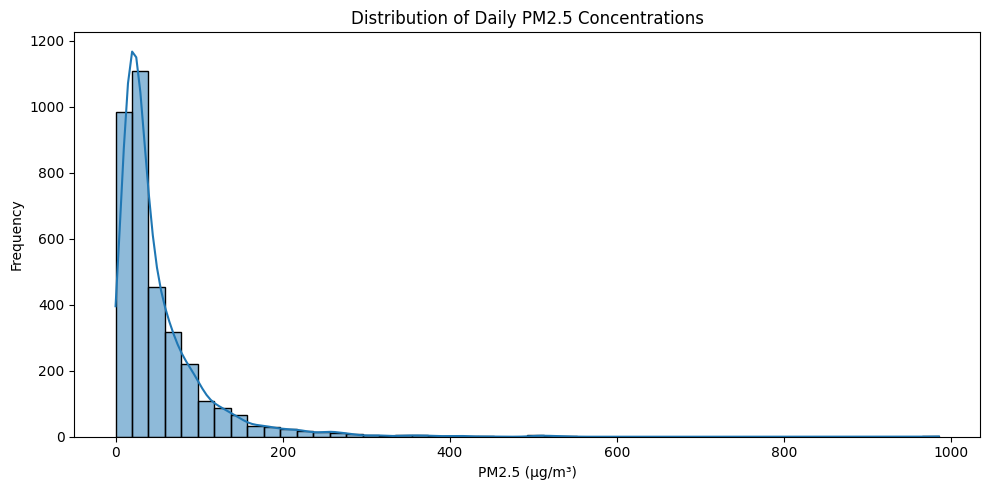

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="PM2.5",
    bins=50,
    kde=True
)

plt.title("Distribution of Daily PM2.5 Concentrations")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
pm25_skewness = df["PM2.5"].skew()

print(
    "PM2.5 skewness:",
    round(pm25_skewness, 3)
)

PM2.5 skewness: 4.106


### 2.2 City-wise PM2.5 Distribution

PM2.5 concentrations are compared across the five cities to identify differences in typical pollution levels, variability, and extreme pollution episodes.

A boxplot provides a visual comparison of the median, interquartile range, and unusually high observations across cities.

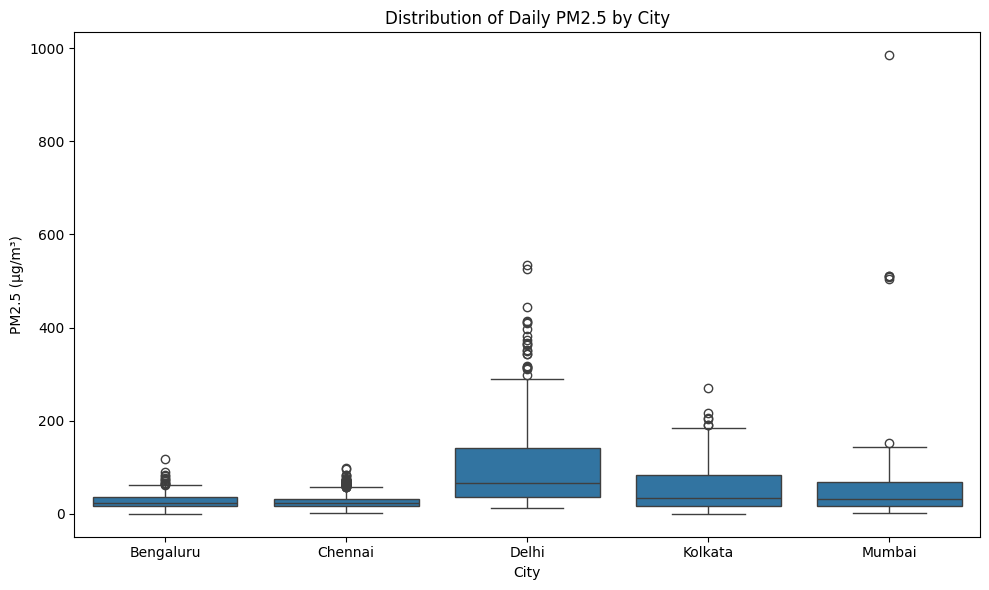

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="City",
    y="PM2.5"
)

plt.title("Distribution of Daily PM2.5 by City")
plt.xlabel("City")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

### 2.3 Monthly PM2.5 Trends

Daily PM2.5 observations were aggregated into monthly averages to visualize temporal changes more clearly.

Monthly aggregation reduces short-term daily fluctuations and helps reveal broader seasonal and city-specific pollution patterns.

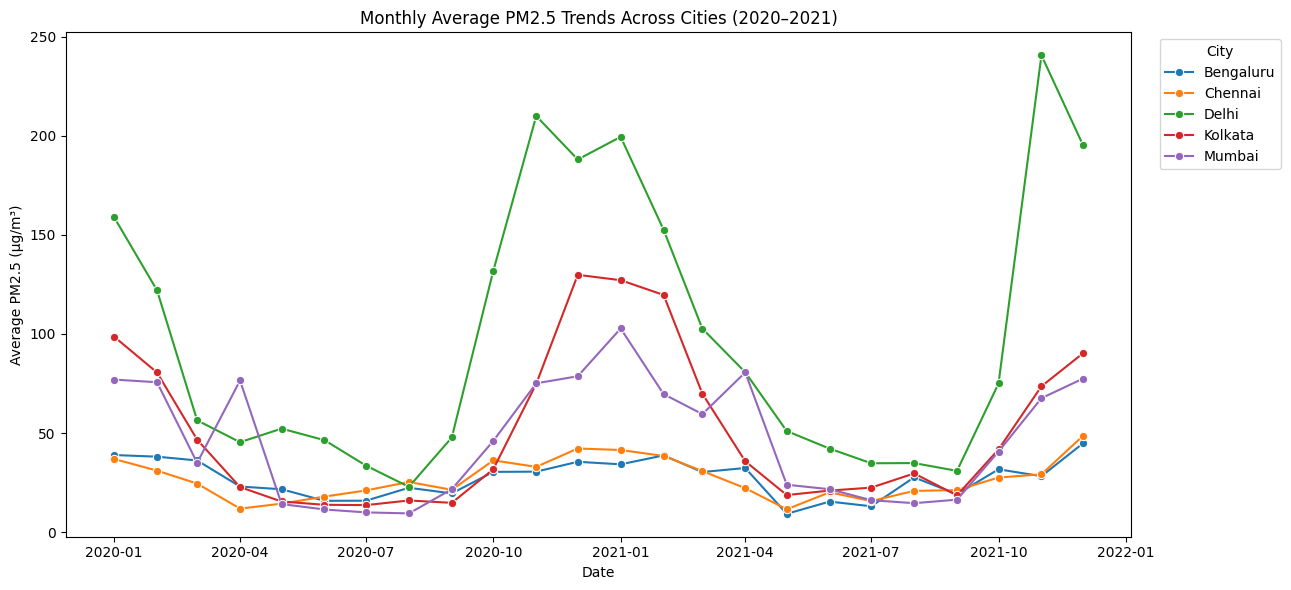

In [ ]:
monthly_pm25 = (
    df
    .set_index("Date")
    .groupby("City")["PM2.5"]
    .resample("MS")
    .mean()
    .reset_index()
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=monthly_pm25,
    x="Date",
    y="PM2.5",
    hue="City",
    marker="o"
)

plt.title(
    "Monthly Average PM2.5 Trends Across Cities (2020–2021)"
)

plt.xlabel("Date")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

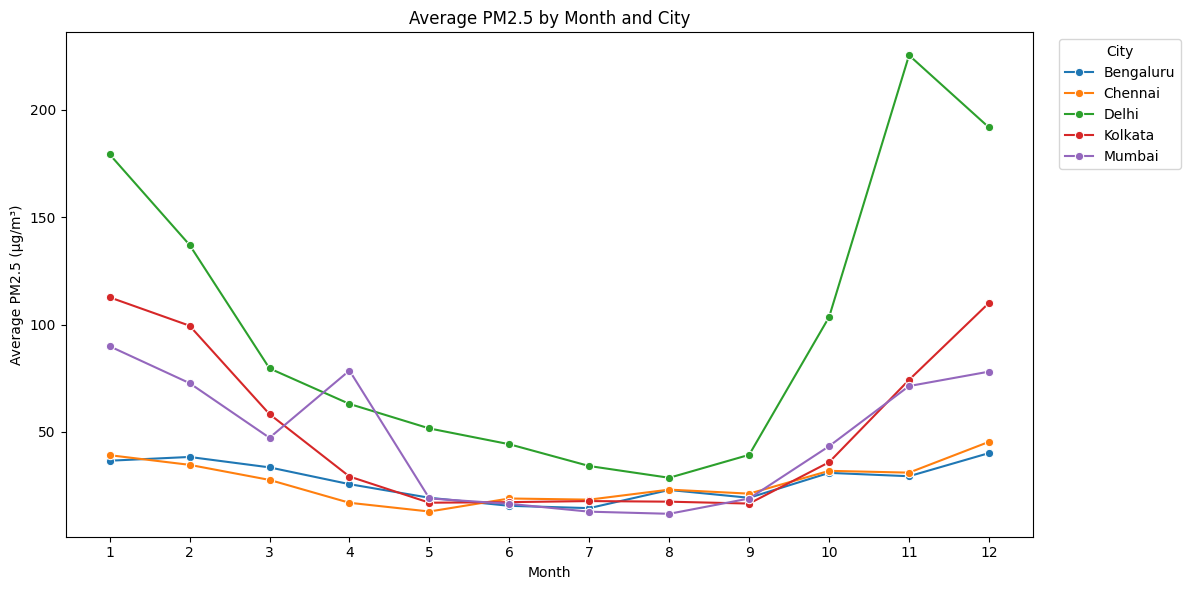

In [ ]:
df["Month"] = df["Date"].dt.month

monthly_pattern = (
    df
    .groupby(["City", "Month"])["PM2.5"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="PM2.5",
    hue="City",
    marker="o"
)

plt.xticks(range(1, 13))

plt.title("Average PM2.5 by Month and City")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 2.4 Relationship Between Air Pollution and Meteorological Factors

To examine potential relationships between air pollutant concentrations and meteorological conditions, correlation analysis was performed using the numerical variables in the dataset.

This provides an initial assessment of the direction and strength of linear associations between pollution levels and weather-related factors.

In [ ]:
# Variables included in correlation analysis

corr_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "O3",
    "CO",
    "Temperature_Mean",
    "Relative_Humidity_Mean",
    "Precipitation",
    "Wind_Speed_Max",
    "Surface_Pressure_Mean"
]

correlation_matrix = df[corr_columns].corr()

display(correlation_matrix.round(2))

,PM2.5,PM10,NO2,SO2,O3,CO,Temperature_Mean,Relative_Humidity_Mean,Precipitation,Wind_Speed_Max,Surface_Pressure_Mean
PM2.5,1.00,0.87,0.67,0.39,-0.00,0.64,-0.51,-0.29,-0.19,-0.30,0.15
PM10,0.87,1.00,0.80,0.50,0.06,0.72,-0.47,-0.47,-0.24,-0.31,0.15
NO2,0.67,0.80,1.00,0.49,0.11,0.61,-0.49,-0.45,-0.21,-0.35,0.05
SO2,0.39,0.50,0.49,1.00,0.14,0.34,-0.16,-0.33,-0.12,-0.22,0.31
O3,-0.00,0.06,0.11,0.14,1.00,0.09,0.13,-0.40,-0.19,-0.04,-0.01
CO,0.64,0.72,0.61,0.34,0.09,1.00,-0.34,-0.30,-0.18,-0.31,0.15
Temperature_Mean,-0.51,-0.47,-0.49,-0.16,0.13,-0.34,1.00,-0.09,0.03,0.21,0.25
Relative_Humidity_Mean,-0.29,-0.47,-0.45,-0.33,-0.40,-0.30,-0.09,1.00,0.38,-0.02,0.09
Precipitation,-0.19,-0.24,-0.21,-0.12,-0.19,-0.18,0.03,0.38,1.00,0.27,0.02
Wind_Speed_Max,-0.30,-0.31,-0.35,-0.22,-0.04,-0.31,0.21,-0.02,0.27,1.00,-0.09


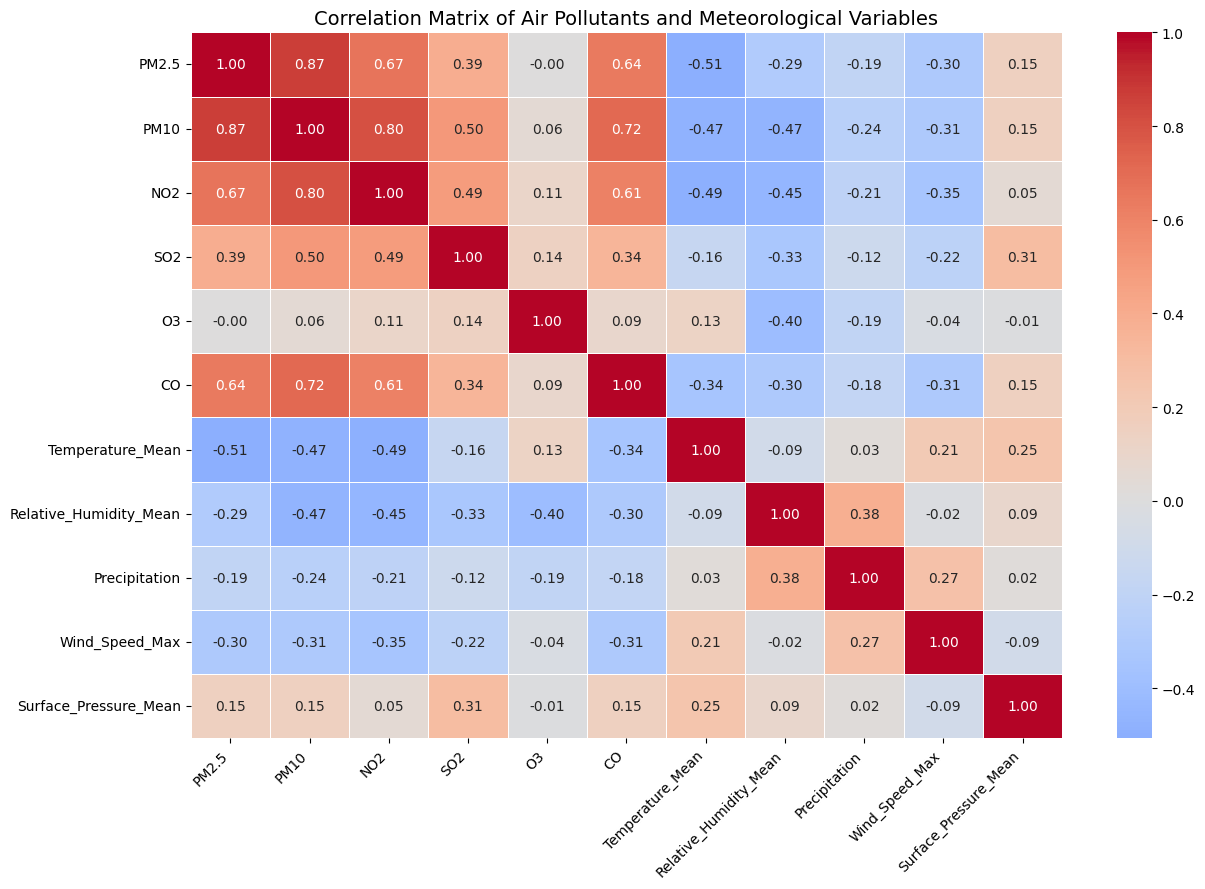

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Air Pollutants and Meteorological Variables",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis reveals substantial relationships among several air pollutants and meteorological variables.

PM2.5 shows a strong positive correlation with PM10 (r = 0.87), followed by NO2 (r = 0.67) and CO (r = 0.64), suggesting that these pollutants may share common emission sources or atmospheric conditions.

Among the meteorological variables, temperature shows the strongest association with PM2.5 (r = -0.51), indicating that higher PM2.5 concentrations tend to occur during periods of lower temperature. Wind speed (r = -0.30), relative humidity (r = -0.29), and precipitation (r = -0.19) also show negative relationships with PM2.5.

O3 shows almost no overall linear correlation with PM2.5. These correlations represent associations rather than causal relationships and may also reflect seasonal and city-specific differences.

## 5. Relationship Between PM2.5 and Meteorological Conditions

Meteorological conditions can influence the accumulation, dispersion, and removal of air pollutants. Scatter plots are used to visually examine the relationships between PM2.5 concentrations and key weather variables.

The variables examined are temperature, relative humidity, precipitation, and wind speed.

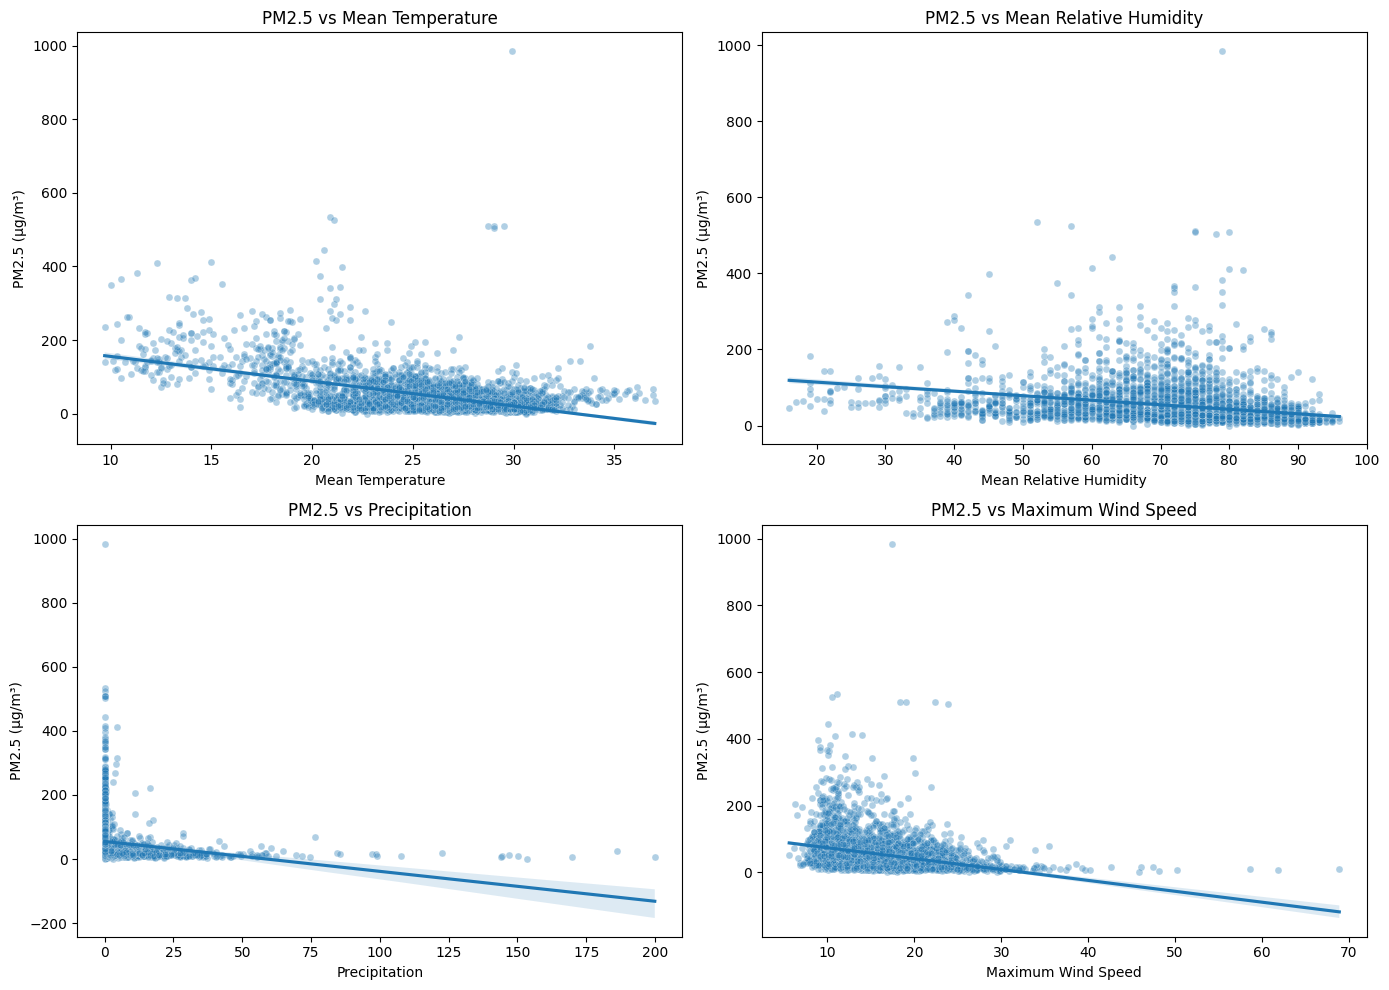

In [ ]:
# Scatter plots of PM2.5 against major meteorological variables

weather_variables = [
    "Temperature_Mean",
    "Relative_Humidity_Mean",
    "Precipitation",
    "Wind_Speed_Max"
]

weather_labels = {
    "Temperature_Mean": "Mean Temperature",
    "Relative_Humidity_Mean": "Mean Relative Humidity",
    "Precipitation": "Precipitation",
    "Wind_Speed_Max": "Maximum Wind Speed"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, variable in zip(axes.flatten(), weather_variables):

    sns.scatterplot(
        data=df,
        x=variable,
        y="PM2.5",
        alpha=0.35,
        s=25,
        ax=ax
    )

    sns.regplot(
        data=df,
        x=variable,
        y="PM2.5",
        scatter=False,
        ax=ax
    )

    ax.set_title(
        f"PM2.5 vs {weather_labels[variable]}"
    )

    ax.set_xlabel(weather_labels[variable])
    ax.set_ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

### Interpretation

The scatter plots indicate that meteorological conditions are associated with variations in daily PM2.5 concentrations.

Temperature shows the clearest negative relationship with PM2.5, with higher concentrations occurring more frequently at lower temperatures. This is consistent with the moderate negative correlation observed earlier.

Wind speed also shows a negative relationship with PM2.5, suggesting that stronger winds may contribute to greater dispersion of particulate matter.

Relative humidity shows a weaker negative association, with substantial variability in PM2.5 across different humidity levels.

Precipitation also exhibits an overall negative relationship with PM2.5. Most high PM2.5 observations occur during periods of little or no rainfall, while higher precipitation levels are generally associated with lower concentrations.

The considerable scatter in all four relationships indicates that meteorological variables alone do not fully explain PM2.5 variation. Pollution levels are likely influenced by a combination of meteorological conditions, other pollutants, seasonal patterns, location-specific effects, and emission sources.

## 6. Temporal Variation in PM2.5 Across Cities

To examine changes in PM2.5 concentrations over time while reducing short-term daily fluctuations, a 30-day rolling average was calculated separately for each city.

This allows broader temporal and seasonal pollution patterns to be observed more clearly.

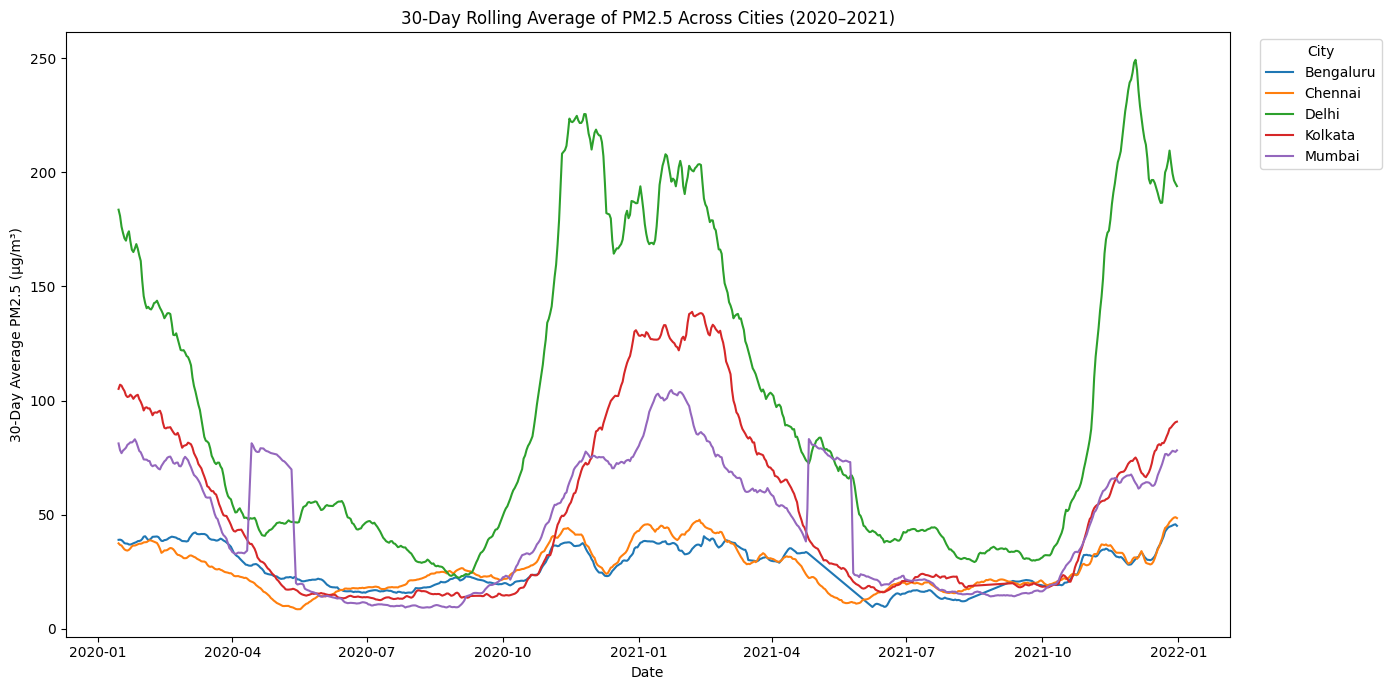

In [ ]:
# Calculate 30-day rolling average of PM2.5 by city

rolling_pm25 = df[
    ["Date", "City", "PM2.5"]
].copy()

rolling_pm25 = rolling_pm25.sort_values(
    ["City", "Date"]
)

rolling_pm25["PM2.5_30Day_Avg"] = (
    rolling_pm25
    .groupby("City")["PM2.5"]
    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=15
        ).mean()
    )
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=rolling_pm25,
    x="Date",
    y="PM2.5_30Day_Avg",
    hue="City"
)

plt.title(
    "30-Day Rolling Average of PM2.5 Across Cities (2020–2021)"
)
plt.xlabel("Date")
plt.ylabel("30-Day Average PM2.5 (µg/m³)")
plt.legend(title="City", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### Interpretation

The 30-day rolling averages reveal clear temporal and seasonal variation in PM2.5 concentrations across the five cities.

Delhi consistently records the highest PM2.5 levels and shows pronounced increases during the colder months, followed by substantial declines during the middle of the year. Kolkata and Mumbai also exhibit seasonal fluctuations, although generally at lower levels than Delhi.

Bengaluru and Chennai maintain comparatively lower and more stable PM2.5 concentrations throughout most of the study period.

Overall, the recurring rise and fall in PM2.5 concentrations indicates that temporal and seasonal information may be important for explaining and predicting air pollution levels. Breaks in some rolling-average series reflect periods of insufficient observations rather than necessarily representing abrupt changes in pollution.

## 7. Seasonal Variation in PM2.5

To further investigate temporal patterns, daily observations were grouped into four broad seasons: Winter, Pre-Monsoon, Monsoon, and Post-Monsoon.

Seasonal averages allow differences in PM2.5 concentrations across climatic periods and cities to be compared more clearly.

In [ ]:
# Create seasonal categories

def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"


seasonal_data = df[
    ["Date", "City", "PM2.5"]
].copy()

seasonal_data["Month"] = seasonal_data["Date"].dt.month

seasonal_data["Season"] = (
    seasonal_data["Month"]
    .apply(assign_season)
)

season_order = [
    "Winter",
    "Pre-Monsoon",
    "Monsoon",
    "Post-Monsoon"
]

seasonal_summary = (
    seasonal_data
    .groupby(
        ["City", "Season"],
        observed=True
    )["PM2.5"]
    .agg(
        Observations="count",
        Mean="mean",
        Median="median"
    )
    .round(2)
    .reset_index()
)

display(seasonal_summary)

,City,Season,Observations,Mean,Median
0,Bengaluru,Monsoon,214,17.60,17.25
1,Bengaluru,Post-Monsoon,113,30.14,25.59
2,Bengaluru,Pre-Monsoon,137,27.21,24.39
3,Bengaluru,Winter,174,38.40,36.73
4,Chennai,Monsoon,239,20.52,20.21
5,Chennai,Post-Monsoon,122,31.50,26.86
6,Chennai,Pre-Monsoon,184,19.27,18.16
7,Chennai,Winter,181,39.91,38.44
8,Delhi,Monsoon,239,36.63,34.00
9,Delhi,Post-Monsoon,122,163.40,141.08


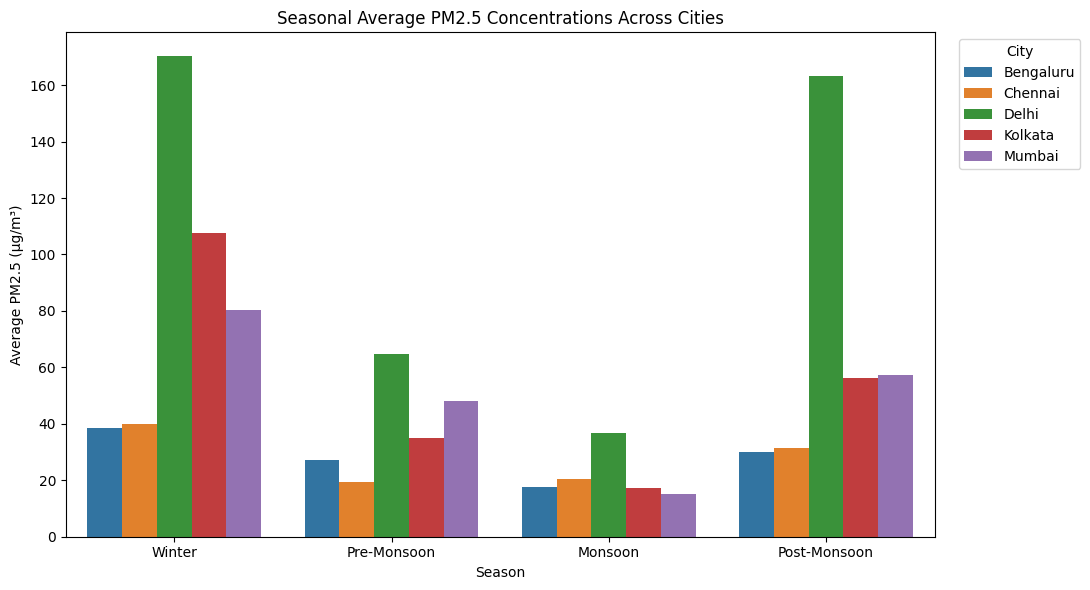

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=seasonal_data,
    x="Season",
    y="PM2.5",
    hue="City",
    order=season_order,
    errorbar=None
)

plt.title(
    "Seasonal Average PM2.5 Concentrations Across Cities"
)

plt.xlabel("Season")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.legend(
    title="City",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

### Interpretation

PM2.5 concentrations show substantial seasonal variation across all five cities.

Delhi records the highest pollution levels, particularly during winter and post-monsoon periods, with average PM2.5 concentrations of approximately 170 and 163 µg/m³, respectively. Concentrations decline considerably during the monsoon season.

Kolkata also exhibits a pronounced seasonal pattern, with substantially higher PM2.5 levels during winter compared with the monsoon period. Mumbai shows higher concentrations during winter and post-monsoon months, while Bengaluru and Chennai generally maintain lower pollution levels with less extreme seasonal variation.

Across most cities, the monsoon season records the lowest PM2.5 concentrations. This may reflect the combined influence of rainfall, atmospheric dispersion, and seasonal changes in emission and meteorological conditions.

The strong seasonal variation suggests that temporal features such as month and season may provide useful predictive information when developing PM2.5 forecasting models.

## 8. Year-wise Variation in PM2.5

Average PM2.5 concentrations were compared between 2020 and 2021 to examine whether pollution levels changed across the two study years.

Because 2020 included periods of substantial changes in transportation and economic activity associated with COVID-19 restrictions, year-wise differences may provide additional context for interpreting temporal pollution patterns.

In [ ]:
# Year-wise PM2.5 summary by city

yearly_data = df[
    ["Date", "City", "PM2.5"]
].copy()

yearly_data["Year"] = yearly_data["Date"].dt.year

yearly_summary = (
    yearly_data
    .groupby(["City", "Year"])["PM2.5"]
    .agg(
        Observations="count",
        Mean="mean",
        Median="median"
    )
    .round(2)
    .reset_index()
)

display(yearly_summary)

,City,Year,Observations,Mean,Median
0,Bengaluru,2020,366,27.34,23.17
1,Bengaluru,2021,272,27.84,25.58
2,Chennai,2020,366,26.37,24.42
3,Chennai,2021,360,27.41,22.41
4,Delhi,2020,366,92.88,61.70
5,Delhi,2021,360,103.95,69.62
6,Kolkata,2020,366,46.56,24.87
7,Kolkata,2021,322,58.04,44.34
8,Mumbai,2020,366,44.05,27.83
9,Mumbai,2021,359,49.70,34.00


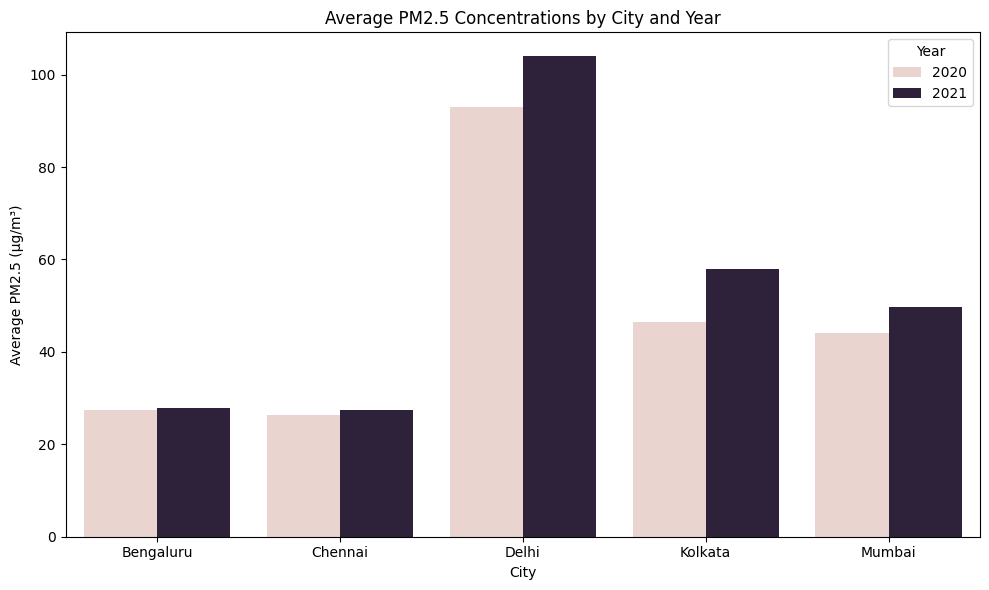

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly_data,
    x="City",
    y="PM2.5",
    hue="Year",
    errorbar=None
)

plt.title("Average PM2.5 Concentrations by City and Year")
plt.xlabel("City")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.legend(title="Year")

plt.tight_layout()
plt.show()

### Interpretation

Average PM2.5 concentrations were higher in 2021 than in 2020 across all five cities, although the magnitude of the difference varied considerably.

Delhi recorded the highest PM2.5 concentrations in both years, with the annual mean increasing from approximately 92.9 µg/m³ in 2020 to 104.0 µg/m³ in 2021. Kolkata and Mumbai also showed noticeable increases, while Bengaluru and Chennai remained comparatively stable.

The lower concentrations observed in 2020 for several cities may partly coincide with changes in transportation, industrial activity, and other emission-generating activities during periods of COVID-19 restrictions. However, the present analysis is observational and does not establish that these restrictions caused the year-to-year differences.

These results indicate that PM2.5 levels vary not only across cities and seasons but also between years, supporting the inclusion of temporal information in subsequent predictive modeling.

## 9. Relationship Between PM2.5 and Other Air Pollutants

PM2.5 concentrations may vary alongside other air pollutants because of shared emission sources and atmospheric processes. The relationships between PM2.5 and the remaining pollutant variables were therefore examined using correlation coefficients.

This analysis also helps identify potentially informative predictors and possible multicollinearity that should be considered during predictive modeling.

In [ ]:
pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "O3",
    "CO"
]

pm25_pollutant_corr = (
    df[pollutant_columns]
    .corr()["PM2.5"]
    .drop("PM2.5")
    .sort_values(ascending=False)
    .round(2)
)

display(
    pm25_pollutant_corr.to_frame(
        name="Correlation_with_PM2.5"
    )
)

,Correlation_with_PM2.5
PM10,0.87
NO2,0.67
CO,0.64
SO2,0.39
O3,-0.00


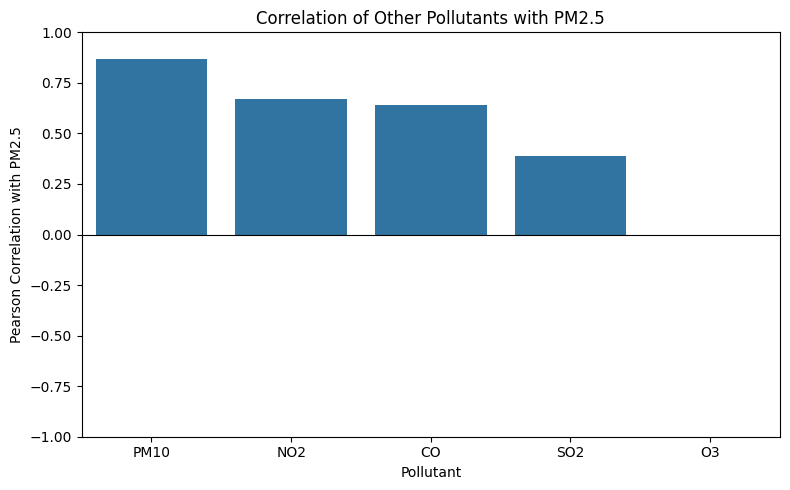

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=pm25_pollutant_corr.index,
    y=pm25_pollutant_corr.values
)

plt.title("Correlation of Other Pollutants with PM2.5")
plt.xlabel("Pollutant")
plt.ylabel("Pearson Correlation with PM2.5")
plt.ylim(-1, 1)

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.tight_layout()
plt.show()

### Interpretation

PM2.5 shows the strongest positive association with PM10, with a Pearson correlation of 0.87. This indicates that days with higher PM10 concentrations also tend to have substantially higher PM2.5 concentrations.

Moderate positive correlations are observed between PM2.5 and NO2 (0.67) and CO (0.64), suggesting that these pollutants may share common emission sources or atmospheric conditions with particulate pollution.

SO2 shows a weaker positive relationship with PM2.5 (0.39), while O3 has essentially no linear correlation with PM2.5 in the combined dataset.

These findings suggest that PM10, NO2, and CO may provide useful predictive information for PM2.5. However, the strong correlations among some pollutant variables should be considered when assessing multicollinearity and designing predictive models.

## 10. Summary of Exploratory Data Analysis

The exploratory analysis revealed substantial spatial and temporal variation in PM2.5 concentrations across the five Indian cities.

Delhi consistently exhibited the highest PM2.5 concentrations and the strongest seasonal fluctuations, with particularly elevated levels during winter and post-monsoon periods. Kolkata and Mumbai also showed considerable seasonal variation, whereas Bengaluru and Chennai generally experienced lower and more stable concentrations.

PM2.5 concentrations were strongly right-skewed, with several high-pollution episodes, particularly in Delhi and Mumbai. Seasonal analysis showed that concentrations were generally lowest during the monsoon period and substantially higher during winter and post-monsoon periods.

Weather conditions were associated with PM2.5 concentrations. Temperature, relative humidity, precipitation, and wind speed generally showed negative relationships with PM2.5, although the strength of these relationships varied.

Among the other pollutants, PM10 showed the strongest positive correlation with PM2.5, followed by NO2 and CO. These relationships indicate that both atmospheric conditions and co-occurring pollutants may provide useful information for predicting PM2.5 concentrations.

The time-series and rolling-average analyses further demonstrated recurring temporal patterns and substantial differences between cities. Overall, the EDA supports the inclusion of temporal, meteorological, pollutant, and city-related information in subsequent statistical analysis and predictive modeling.